In [1]:
from src.objetos import dados, rede_neural, camada_densa

In [2]:
caminho_dados = r"dados/image_test.csv"
caminho_rotulos = r"dados/label_test.csv"

In [3]:
dados = dados.Dados(caminho_dados,caminho_rotulos,3)
dados.conjunto_treinamento = (dados.pacote_dados, dados.one_hot_rotulos)

In [4]:
epocas = 100
taxa_aprendizado = 2
lambda_reg = None
# [A,B,C] : A -> B -> C
arquitetura_camadas = [3, 5, 3]

In [5]:
camadas = []

for i in range(len(arquitetura_camadas)-2):
    camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[i], 
        tamanho_saida=arquitetura_camadas[i+1],
        funcao_de_ativacao='sigmoid'
        )
    camadas.append(camada)
# Aplica softmax na ultima camada
camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[-2], 
        tamanho_saida=arquitetura_camadas[-1],
        funcao_de_ativacao='softmax'
        )
camadas.append(camada)

In [6]:
rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

In [7]:
rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_reg,
    verificacao_gradiente=True
)

In [8]:
import pandas as pd

logs = pd.read_csv("log_treinamento.csv")

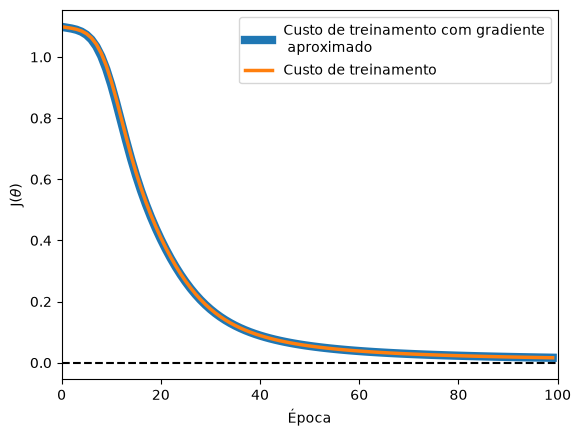

In [9]:
from matplotlib import pyplot as plt
plt.figure()
plt.plot(logs["epoca"],logs["gradiente_aproximado"],label="Custo de treinamento com gradiente\n aproximado", linewidth=6)
plt.plot(logs["epoca"],logs["custo_treinamento"],label="Custo de treinamento", linewidth=2.5)

plt.hlines(0.0,logs["epoca"][0],logs["epoca"].iloc[-1]+1,linestyles="--", colors="black")
plt.xlabel("Época")
plt.ylabel(r"J$(\theta)$")
plt.legend()
plt.xlim(logs["epoca"].iloc[0],logs["epoca"].iloc[-1]+1)
plt.show()

/tmp/ipykernel_103819/1694768178.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


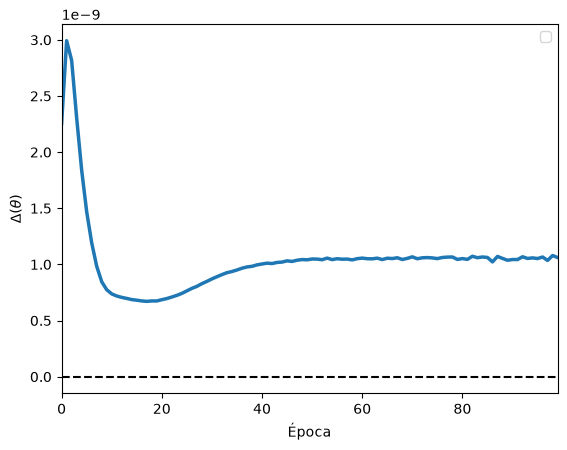

In [10]:
import numpy as np
plt.figure()

plt.plot(logs["epoca"],logs["difereca_gradiente"],label="", linewidth=2.5)
plt.hlines(0.0, logs["epoca"].iloc[0],logs["epoca"].iloc[-1], colors="black", linestyles="--")
plt.xlabel("Época")
plt.ylabel(r"$\Delta(\theta)$")
plt.legend()
plt.xlim(logs["epoca"].iloc[0],logs["epoca"].iloc[-1])
plt.show()
